In [12]:
import numpy as np
import seaborn as sns
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from time import time

In [13]:
def VanDerPol_sys(t, X, mu):
    x,v = X
    dxdt = v
    dvdt = mu * (1-x**2)*v - x
    return np.array([dxdt, dvdt])

# VanDerPol_sys(1, np.array([1,4]), 1.5)

## Solution 

In [ ]:
def generate_vanderpol_solution(mu : float, X0 : np.array, t_span : np.array, freq : float, verbose=False):
    # mu = 0
    # X0 = np.array([1,0])
    start_time = time()
    t_start, t_end = t_span[0], t_span[1]
    # freq = 10 # n time steps per second
    t  = np.linspace(t_start, t_end, int(freq*(t_end- t_start)))

    sol = solve_ivp(
        VanDerPol_sys,
        t_span,
        X0,
        t_eval=t,
        args=(mu,),
        dense_output=True
    )
    x = sol.y[0]
    v = sol.y[1]
    end_time = time()
    if verbose:
        print(f"{end_time-start_time} seconds to generate soln.")
    return x,v,sol.t, sol

## Timeseries

In [15]:
def plot_time_series_range(sol_t, x, v, mu, t_start = 0, t_end = 1):
    start_inter = int(len(sol_t)*t_start)
    end_inter   = int(len(sol_t)*t_end)

    plt.plot(sol_t[start_inter:end_inter], x[start_inter:end_inter], label="x (position)")
    plt.plot(sol_t[start_inter:end_inter], v[start_inter:end_inter], label="v (velocity)")
    plt.xlabel("Time (t)")
    plt.ylabel("State variables")
    plt.title(f"Van der Pol Oscillator Time Series (\u03bc={mu})"  + (" No damping" if mu==0 else " "))
    plt.legend()
    plt.grid(True)
    plt.show()
# x = sol.y[0]
# v = sol.y[1]


## Phase portrait

In [ ]:
# Phase Portrait
def plot_phase_portrait(x, v, X0,mu, t_start=0, t_end=1):
    start_inter = int(len(x)*t_start)
    end_inter   = int(len(x)*t_end)
    plt.figure(figsize=(6, 6))
    plt.plot(x[start_inter:end_inter], v[start_inter:end_inter], label=f"μ={mu}")
    plt.plot(X0[0], X0[1], 'go', label="Start Point")
    plt.xlabel("x")
    plt.ylabel("v = dx\n      dt")
    plt.title(f"Van der Pol Oscillator Phase Portrait (\u03bc={mu})" + (" No damping" if mu==0 else " "))
    plt.axis("equal")
    plt.legend()
    plt.grid(True)
    plt.show()  



### For $\mu$ = 0: Remains at limit cycle

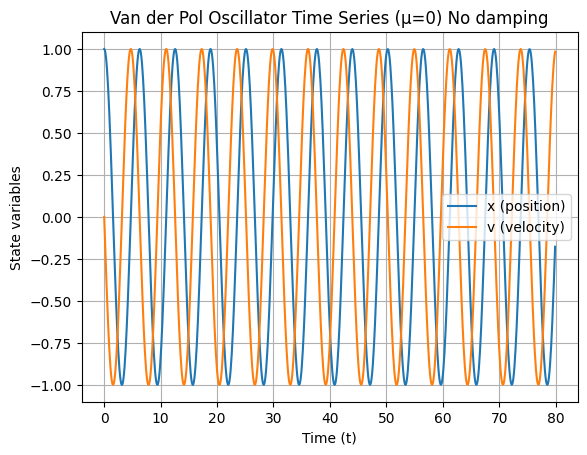

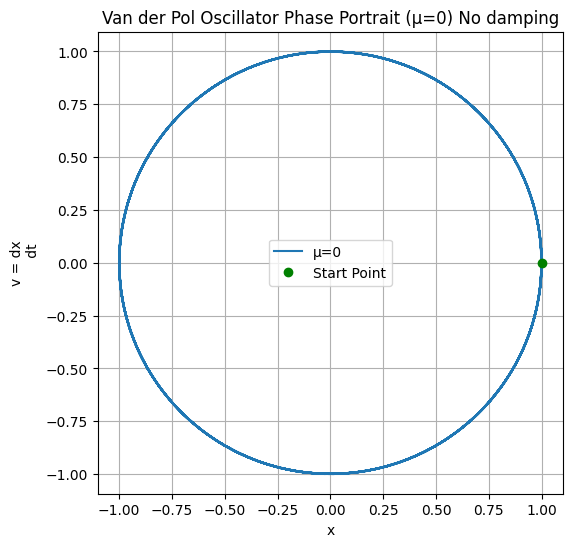

In [ ]:
X0 = np.array([1,0])
mu = 0
x,v,sol_t,sol = generate_vanderpol_solution(
    mu=mu,
    X0=X0,
    t_span=np.array([0,1000]),
    freq=10
)
plot_time_series_range(sol_t, x, v, mu, t_start=0, t_end=0.08)
plot_phase_portrait(x, v,X0, mu, 0, 0.08) 

### For $\mu$ > 0: Unstable point

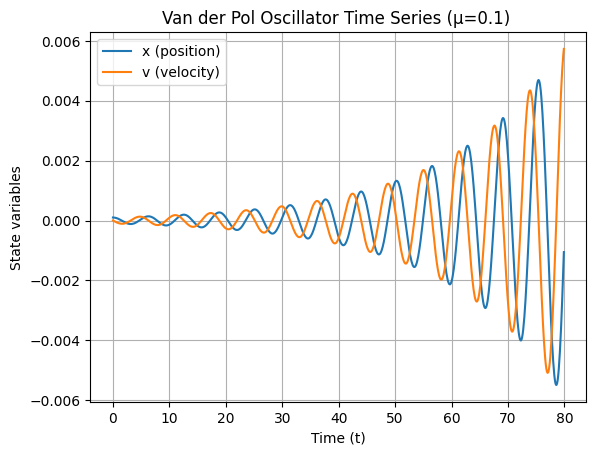

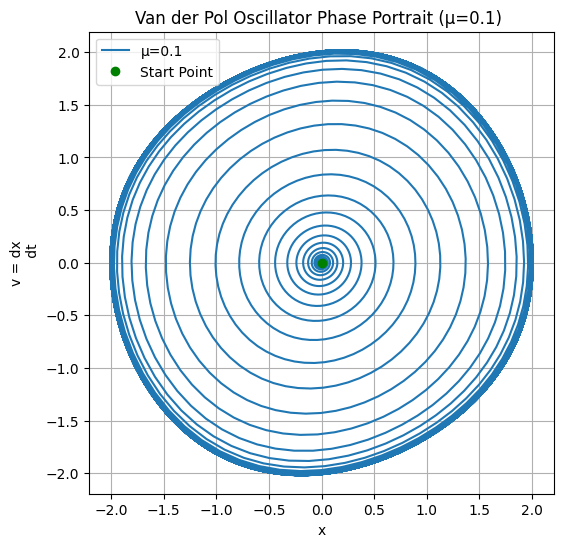

In [ ]:
X0 = np.array([0.0001,0])
mu = 0.1
x,v,sol_t,sol = generate_vanderpol_solution(
    mu=mu,
    X0=X0,
    t_span=np.array([0,1000]),
    freq=10
)
plot_time_series_range(sol_t, x, v, mu, t_start=0, t_end=0.08)
plot_phase_portrait(x, v,X0, mu, 0, 1) 

### For $\mu$ < 0: Stable point at (0,0)

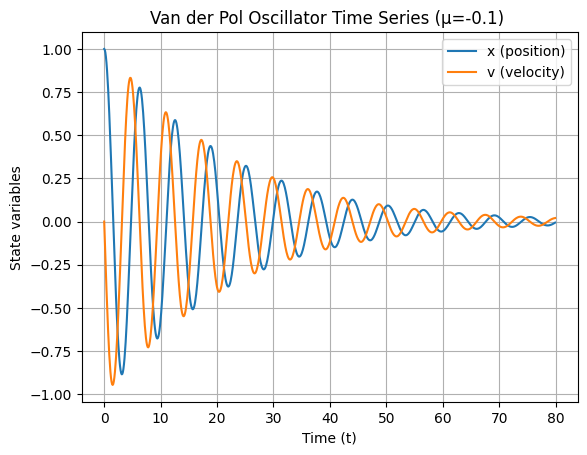

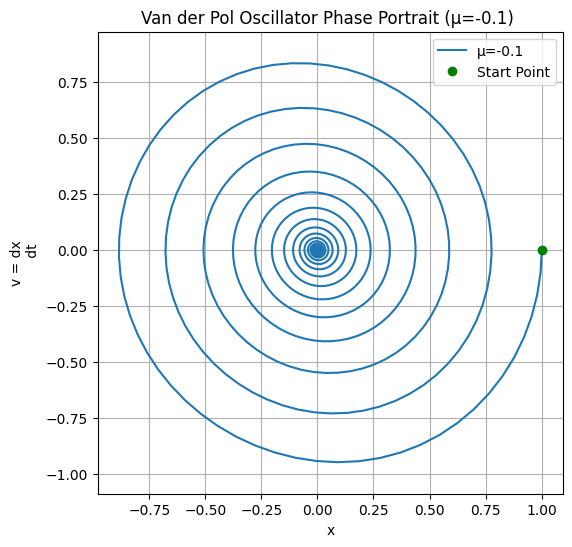

In [ ]:
X0 = np.array([1,0])
mu = -0.1
x,v,sol_t,sol = generate_vanderpol_solution(
    mu=mu,
    X0=X0,
    t_span=np.array([0,1000]),
    freq=10
)
plot_time_series_range(sol_t, x, v, mu, t_start=0, t_end=0.08)
plot_phase_portrait(x, v,X0, mu, 0, 1) 

### Limit cycles as $\mu$ increases

In [20]:
from scipy import constants
from scipy.signal import find_peaks


In [21]:
mu = 0.1
def T_mu_period(mu):
    return 2 * constants.pi / (1 - ((mu**2)/16) + (17 * (mu**4) / 3072))
T_mu_period(mu)

6.287111272529225

In [22]:
freq = 100
t = np.linspace(0, 0.5, freq+1)
mu_periods = T_mu_period(t)
# plt.plot(t, mu_periods)

0.0, 0.04, 0.08, 0.12, 0.16, 0.2, 

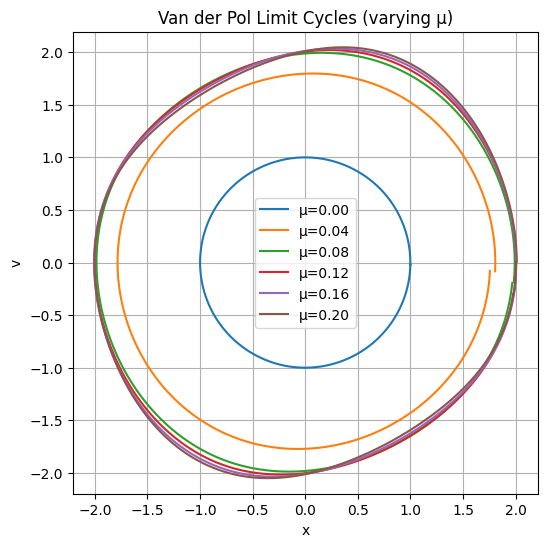

In [23]:
plt.figure(figsize=(6,6))
mu_values = np.linspace(0, 0.2, 6)
[print(mu_value, end=', ') for mu_value in mu_values]
for mu in mu_values:
    T = T_mu_period(mu)
    t_span = (0, 10*T)

    x, v, t, _ = generate_vanderpol_solution(mu, X0, t_span, freq=200)

    t_start = t[-1] - T
    mask = t >= t_start

    plt.plot(x[mask], v[mask], label=f"\u03bc={mu:.2f}")

plt.xlabel("x")
plt.ylabel("v")
plt.title("Van der Pol Limit Cycles (varying \u03bc)")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

##  Poincaré section/map

In [ ]:
def poincare_section(sol, omega, save=True, res_index = 10):
    """
    Sample the solution at multiples of the driving period T = 2π/ω.
    """
    T = 2 * np.pi / omega
    t_start = sol.t[0] + 0.2 * (sol.t[-1] - sol.t[0])
    t_end   = sol.t[-1]

    n_start = int(np.ceil((t_start - sol.t[0]) / T))
    n_end   = int(np.floor((t_end   - sol.t[0]) / T))
    sample_times = sol.t[0] + np.arange(n_start, n_end + 1) * T

    states = sol.sol(sample_times)   # shape (2, N)
    px = states[0]
    pv = states[1]

    plt.figure(figsize=(6, 6))
    plt.scatter(px, pv, c='navy', alpha=0.6, linewidths=0, s = 0.1/res_index)
    plt.title(f"Poincaré Section (Van Der Pol)  (T = 2.pi/w, w = {omega})")
    plt.xlabel("x")
    plt.ylabel("ẋ")
    plt.grid(True, lw=0.4)
    plt.tight_layout()

    if save:
        plt.savefig("output.png", dpi=100*res_index, bbox_inches='tight')

    return px, pv

177.74496603012085 seconds to generate soln.


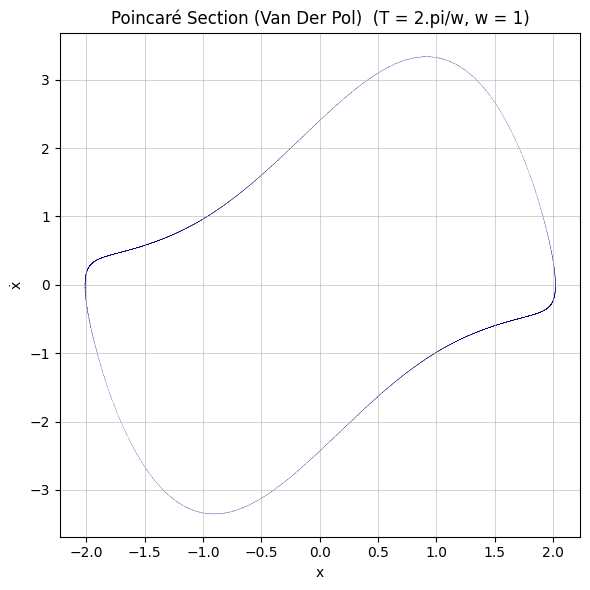

In [25]:
t_span = np.array([0,500_000])
mu=1.6
omega=1
x1, x2, sol_t, sol = generate_vanderpol_solution(mu, X0, t_span, freq, verbose=True)
# time_series(x1, x2, sol_t)
# phase_portrait(x1, x2)
px, pv = poincare_section(sol, omega)